# 📝 Exercise M1.02
The goal of this exercise is to fit a similar model as in the previous notebook to get familiar with manipulating scikit-learn objects and in particular the .fit/.predict/.score API.

Let’s load the adult census dataset with only numerical variables

In [1]:
import pandas as pd

adult_census = pd.read_csv("datasets/adult-census-numeric.csv")
data = adult_census.drop(columns="class")
target = adult_census["class"]

In the previous notebook we used model = KNeighborsClassifier(). All scikit-learn models can be created without arguments. This is convenient because it means that you don’t need to understand the full details of a model before starting to use it.

One of the KNeighborsClassifier parameters is n_neighbors. It controls the number of neighbors we are going to use to make a prediction for a new data point.

What is the default value of the n_neighbors parameter?

Hint: Look at the documentation on the scikit-learn website or directly access the description inside your notebook by running the following cell. This opens a pager pointing to the documentation.

In [2]:
from sklearn.neighbors import KNeighborsClassifier

KNeighborsClassifier?

Init signature:
KNeighborsClassifier(
    n_neighbors=5,
    *,
    weights='uniform',
    algorithm='auto',
    leaf_size=30,
    p=2,
    metric='minkowski',
    metric_params=None,
    n_jobs=None,
)
Docstring:     
Classifier implementing the k-nearest neighbors vote.

Read more in the :ref:`User Guide <classification>`.

Parameters
----------
n_neighbors : int, default=5
    Number of neighbors to use by default for :meth:`kneighbors` queries.

weights : {'uniform', 'distance'}, callable or None, default='uniform'
    Weight function used in prediction.  Possible values:

    - 'uniform' : uniform weights.  All points in each neighborhood
      are weighted equally.
    - 'distance' : weight points by the inverse of their distance.
      in this case, closer neighbors of a query point will have a
      greater influence than neighbors which are further away.
    - [callable] : a user-defined function which accepts an
      array of distances, and returns an array of the same shape

Create a KNeighborsClassifier model with n_neighbors=50

In [3]:
model_k50 = KNeighborsClassifier(n_neighbors=50)

Fit this model on the data and target loaded above

In [4]:
import numpy as np

# Remove all non-numeric columns
data = data.select_dtypes(include=[np.number])


In [5]:
# Check the new data
data.head()


,id,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,1,25,226802,7,0,0,40
1,2,38,89814,9,0,0,50
2,3,28,336951,12,0,0,40
3,4,44,160323,10,7688,0,40
4,5,18,103497,10,0,0,30


In [6]:
from sklearn.model_selection import train_test_split

# Create the dataset
train_data, test_data, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42)

In [7]:
# Fit the model
model_k50.fit(train_data, train_target)

,n_neighbors,50
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Use your model to make predictions on the first 10 data points inside the data. Do they match the actual target values?

In [8]:
# Make predictions on the first 10 data points
predictions = model_k50.predict(test_data[:10])
predictions

array(['<=50K', '<=50K', '>50K', '<=50K', '<=50K', '<=50K', '<=50K',
       '<=50K', '<=50K', '<=50K'], dtype=object)

Compute the accuracy on the training data.

In [9]:
# Compute the accuracy on the training data
accuracy = model_k50.score(train_data, train_target)
accuracy


0.7832774550200906

Now load the test data from "../datasets/adult-census-numeric-test.csv" and compute the accuracy on the test data.

In [10]:
# Test the model
accuracy = model_k50.score(test_data, test_target)
accuracy

0.7883099600777971

# Let's optimize the value of K

In [11]:
data.shape

(48842, 7)

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.metrics import make_scorer

# Create a new KNN model
model_reloaded = KNeighborsClassifier()
param_grid = {'n_neighbors': range(3, 23)}

# f1
f1_macro = make_scorer(f1_score, average="macro")

grid_search = GridSearchCV(
    estimator=model_reloaded,
    param_grid=param_grid,
    cv=5, # 5 or 10 are the most common values in the industry
    scoring={
        "accuracy": "accuracy",
        "f1_macro": f1_macro,
    },
    refit="accuracy"
)
grid_search.fit(X=train_data, y=train_target)

optimal_k = grid_search.best_params_['n_neighbors']
results = grid_search.cv_results_
print(f"The optimal number of neighbors is {optimal_k}")


The optimal number of neighbors is 12


### Plot Accuracy vs K

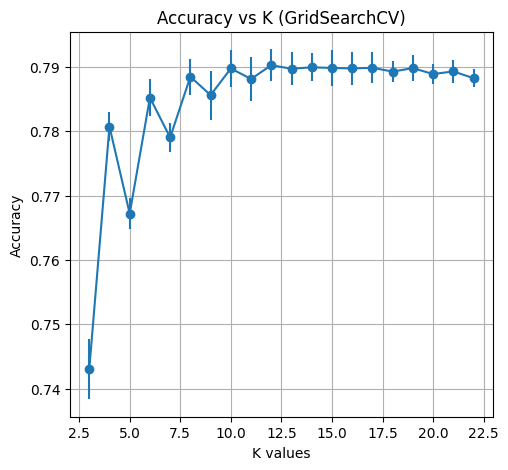

In [13]:
import matplotlib.pyplot as plt

# Take the best K values
k_values = results["param_n_neighbors"]
mean_acc = results["mean_test_accuracy"]
std_acc = results["std_test_accuracy"]

# Init the plot
plt.figure(figsize=(12, 5))

# tune the plot
plt.subplot(1, 2, 1)
plt.errorbar(k_values, mean_acc, yerr=std_acc, fmt='-o')
plt.title("Accuracy vs K (GridSearchCV)")
plt.xlabel("K values")
plt.ylabel("Accuracy")
plt.grid(True)

In [14]:
# Let's check the F1 macro first
f1_macro_result = results["mean_test_f1_macro"]
f1_macro_std = results["std_test_f1_macro"]

f1_macro_result


array([0.58443668, 0.57547173, 0.58565917, 0.57235807, 0.580696  ,
       0.57074715, 0.57807728, 0.56763774, 0.57292945, 0.56400767,
       0.56785176, 0.56037717, 0.56392813, 0.55824815, 0.56085478,
       0.55507609, 0.55845345, 0.55247458, 0.55488122, 0.54937615])

In [15]:
# Print the unique classes
print(np.unique(target))

['<=50K' '>50K']


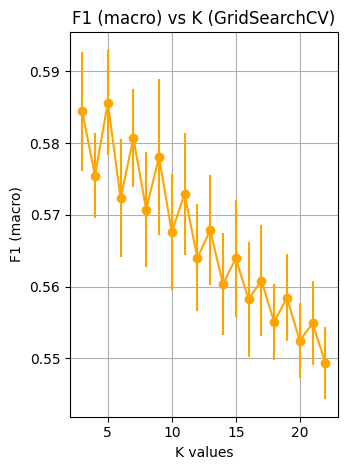

In [16]:
# F1 macro vs K
mean_f1 = results["mean_test_f1_macro"]
std_f1 = results["std_test_f1_macro"]

plt.subplot(1, 2, 2)
plt.errorbar(k_values, mean_f1, yerr=std_f1, fmt='-o', color='orange')
plt.title("F1 (macro) vs K (GridSearchCV)")
plt.xlabel("K values")
plt.ylabel("F1 (macro)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [17]:
# Let's train a single model with the optimal K
model_k12 = KNeighborsClassifier(n_neighbors=12)
model_k12.fit(train_data, train_target)

# Get the predictions
y_pred_k12 = model_k12.predict(test_data)


In [18]:
from sklearn.metrics import classification_report

# f1 score - macro
f1_macro_k12 = f1_score(test_target, y_pred_k12, average="macro")
print(f"The F1 macro score is {f1_macro_k12}")

# f1 score by class
f1_by_class = f1_score(test_target, y_pred_k12, average=None)
print(f"The F1 score by class is (K=12): {f1_by_class}")

# complete a report
print(classification_report(test_target, y_pred_k12))


The F1 macro score is 0.5799915307692807
The F1 score by class is (K=12): [0.88275534 0.27722772]
              precision    recall  f1-score   support

       <=50K       0.80      0.99      0.88      7479
        >50K       0.86      0.17      0.28      2290

    accuracy                           0.80      9769
   macro avg       0.83      0.58      0.58      9769
weighted avg       0.81      0.80      0.74      9769



### Conclusion
To improve performance on the >50K class, you need approaches that are actually used in industry—not theoretical tweaks:

**Rebalancing the dataset**
Techniques like SMOTE, undersampling, oversampling, or using class weights (though KNN doesn't support them directly) help correct the dominance of the <=50K class.

**Proper feature normalization**
KNN is extremely sensitive to feature scales. Standardizing or normalizing the data is mandatory for any meaningful improvement.

**Switching to more suitable models**
On the Adult Income dataset, models that consistently outperform KNN—especially on the >50K minority class—are:
- Regularized Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM

*These models substantially improve recall for >50K.*

**Better feature engineering**
KNN struggles with:
- noisy features
- correlated features
- overlapping clusters
- categorical variables encoded too crudely

Tree-based and linear models handle these issues far better.

**Practical reading of the results**
Your current KNN model:
- Performs very well on the majority class (<=50K).
- Performs poorly on the minority class (>50K).
- Shows high accuracy, which hides the imbalance problem.
- Shows low macro F1, which correctly exposes the imbalance.

This behavior is expected.
K=12 is not the issue—KNN simply isn’t a good fit for this dataset.